### 🚢 **05. Arbre de Décision vs Forêt Aléatoire (Random Forest)**

Dans ce dernier notebook, nous allons comparer un modèle simple (l'arbre) avec un modèle d'ensemble puissant (la forêt).

---

#### **Objectif**
Prédire la survie des passagers du Titanic.

#### 📌 **Plan du notebook**
- 📥 Chargement des données Titanic
- 🧹 Nettoyage rapide (Preprocessing)
- 🌳 Entraînement d'un Arbre de Décision
- 🌲 Entraînement d'une Forêt Aléatoire
- 📊 Comparaison des performances et importance des variables

### 📥 **Chargement des librairies**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

print("✅ Librairies prêtes !")

✅ Librairies prêtes !


### 📊 **Chargement du dataset Titanic**

🔗 Lien Kaggle : [Titanic - Machine Learning from Disaster](https://www.kaggle.com/c/titanic)

In [4]:
df = sns.load_dataset('titanic')  # chargement du jeu de données Titanic ( intégrée dans Seaborn )
df.info()  
df.size  

df.head()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
# Sélection de quelques variables simples et suppression des lignes avec des valeurs manquantes 
df = df[['survived', 'pclass', 'sex', 'age', 'fare']].dropna()


# Transformation du sexe en nombre (0 ou 1) 
df['sex'] = df['sex'].map({'male': 0, 'female': 1})

df.head()

,survived,pclass,sex,age,fare
0,0,3,0,22.0,7.2500
1,1,1,1,38.0,71.2833
2,1,3,1,26.0,7.9250
3,1,1,1,35.0,53.1000
4,0,3,0,35.0,8.0500


### ✂️ **Division Train/Test**

In [6]:
X = df.drop('survived', axis=1)
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 🌳 **Modèle 1 : Arbre de Décision**

Un arbre prend des décisions successives (ex: Sexe == Femme ? -> Oui -> Survie).

In [ ]:
tree = DecisionTreeClassifier(max_depth=3, 
                              random_state=42)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

print(f"Précision Arbre : {accuracy_score(y_test, y_pred_tree):.4f}")

Précision Arbre : 0.7413


### 🌲 **Modèle 2 : Forêt Aléatoire**

Une forêt est une collection d'arbres qui votent. C'est beaucoup plus robuste.

In [8]:
rf = RandomForestClassifier(n_estimators=100,  # nombre de arbres
                            random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(f"Précision Forêt Aléatoire : {accuracy_score(y_test, y_pred_rf):.4f}")

Précision Forêt Aléatoire : 0.7622


### 📊 **Importance des variables**

Quels facteurs ont le plus compté pour la survie ?

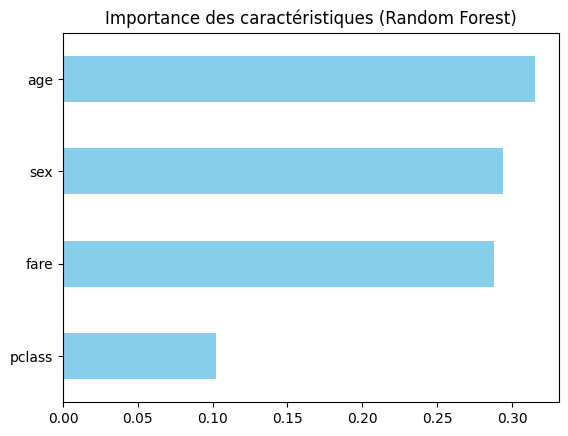

In [11]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', color='skyblue')
plt.title("Importance des caractéristiques (Random Forest)")
plt.show()

### ✅ **Conclusion**

- **Arbre de Décision** : Facile à visualiser mais tendance à l'overfitting.
- **Random Forest** : Plus précis et stable car il réduit la variance en combinant plusieurs arbres.